In [20]:
import pandas as pd
import numpy as np

In [90]:
df = pd.read_csv("Student_performance.csv")

In [91]:
df = df.sample(10000)
df = df.iloc[:,:-1]
df

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
494183,494184,21.7,77.7,8.4,100.0
952767,952768,10.0,85.6,4.0,61.7
932073,932074,29.2,94.3,2.3,100.0
729338,729339,26.3,89.8,3.2,92.5
979857,979858,14.2,83.9,4.6,73.3
...,...,...,...,...,...
152559,152560,10.8,83.5,7.5,80.7
920990,920991,12.4,85.8,5.2,83.1
347734,347735,10.8,83.7,6.5,75.9
697236,697237,19.8,74.6,8.7,94.6


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 494183 to 89860
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               10000 non-null  int64  
 1   weekly_self_study_hours  10000 non-null  float64
 2   attendance_percentage    10000 non-null  float64
 3   class_participation      10000 non-null  float64
 4   total_score              10000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 468.8 KB


In [93]:
df.describe()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,501254.077100,15.117160,84.818020,5.989810,84.540330
std,290497.422829,6.775234,9.391479,1.961914,15.231971
min,93.000000,0.000000,50.000000,0.000000,25.600000
25%,247099.000000,10.400000,78.400000,4.600000,74.400000
50%,500715.500000,15.100000,85.200000,6.000000,87.700000
75%,753016.000000,19.800000,91.900000,7.400000,100.000000
max,999580.000000,40.000000,100.000000,10.000000,100.000000


In [94]:
import matplotlib.pyplot as plt 
import seaborn as sns

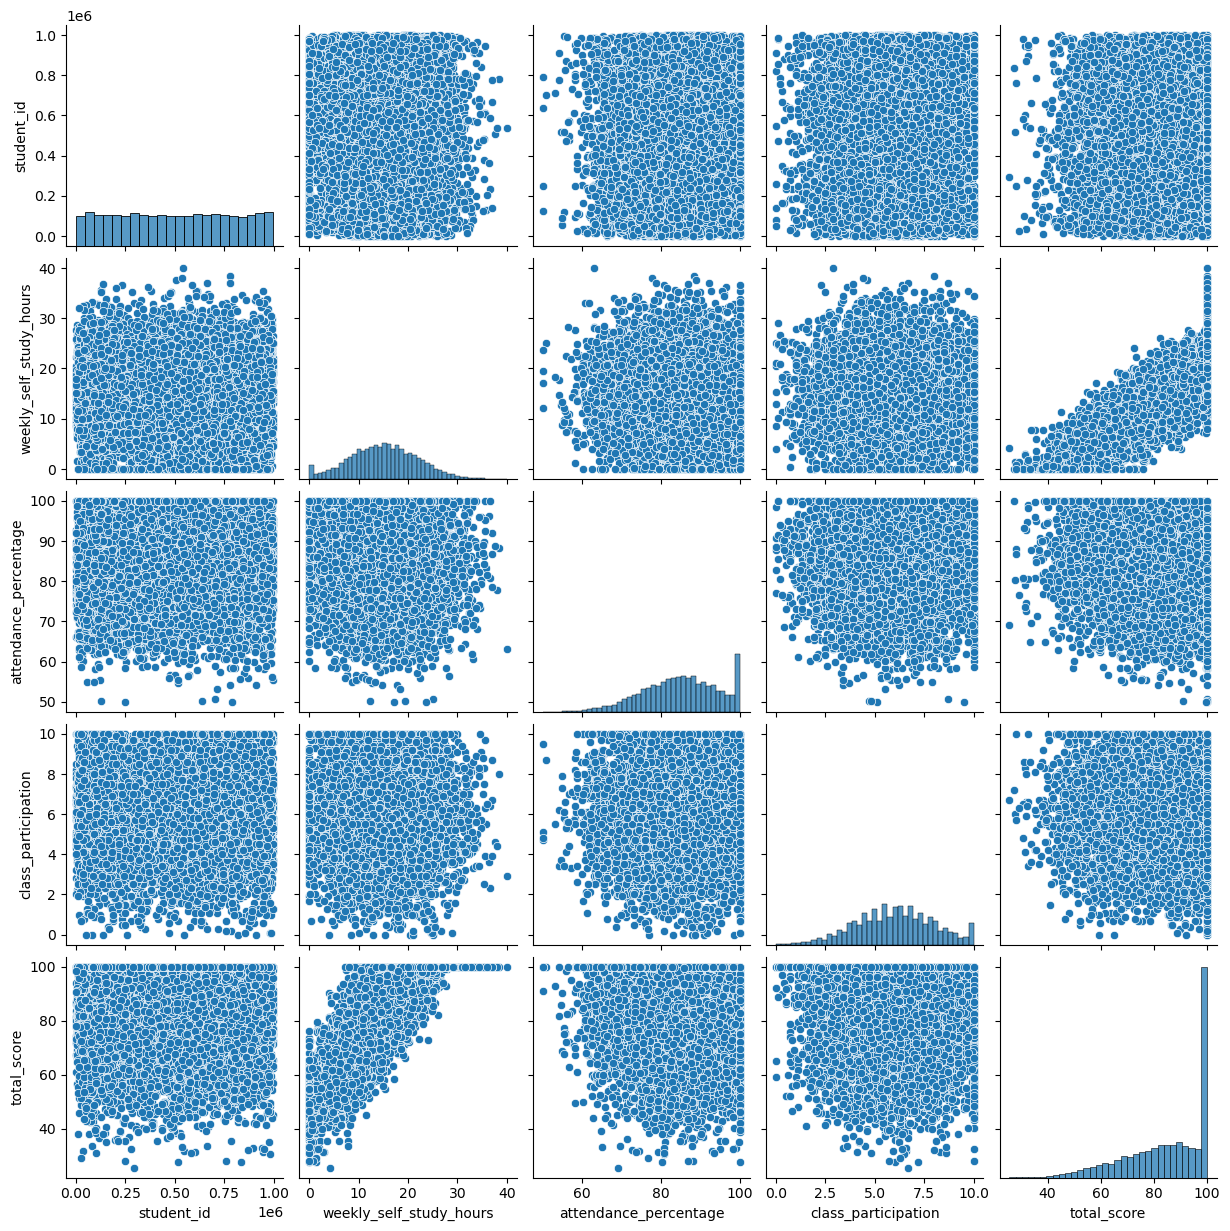

In [95]:
sns.pairplot(df)

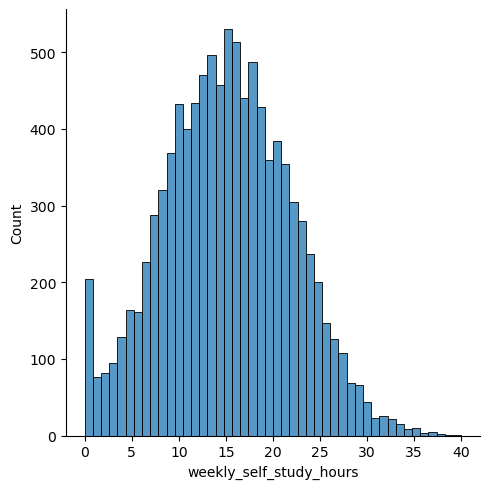

In [96]:
sns.displot(df["weekly_self_study_hours"])

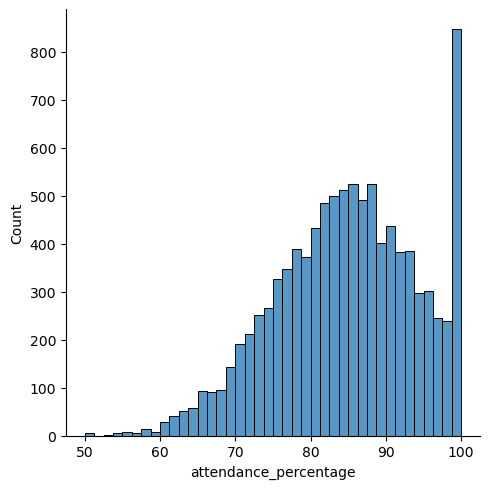

In [97]:
sns.displot(df["attendance_percentage"])

In [103]:
nf = df["attendance_percentage"]**3

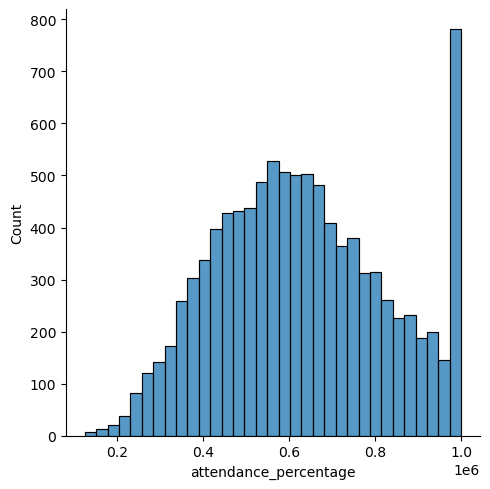

In [104]:
#new distribution after applying cube transformation
sns.displot(nf)

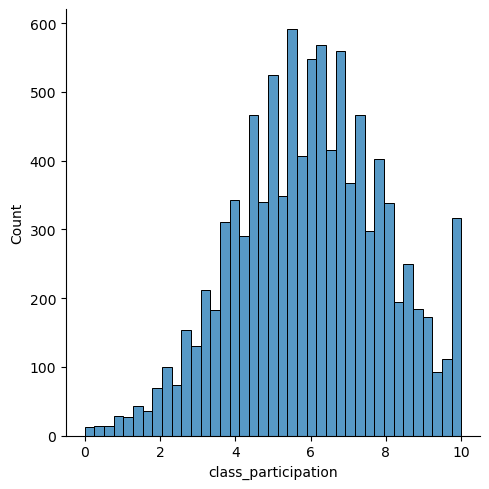

In [105]:
sns.displot(df["class_participation"])

In [106]:
df.skew()

student_id                 0.003884
weekly_self_study_hours    0.067739
attendance_percentage     -0.295263
class_participation       -0.106167
total_score               -0.834382
dtype: float64

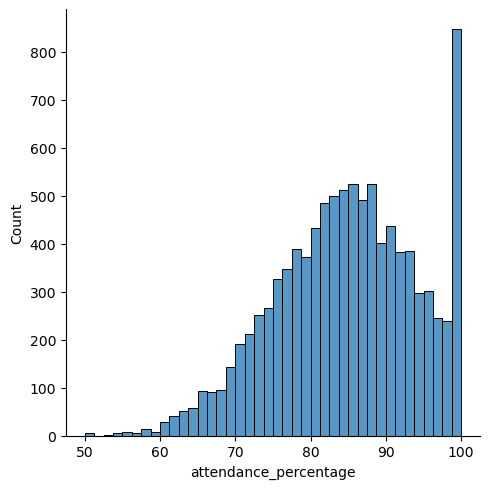

In [107]:
sns.displot(df["attendance_percentage"])

<Axes: xlabel='class_participation'>

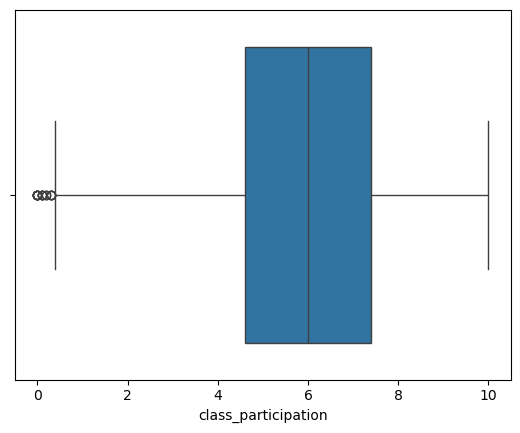

In [108]:
sns.boxplot(x=df["class_participation"])

<Axes: xlabel='attendance_percentage'>

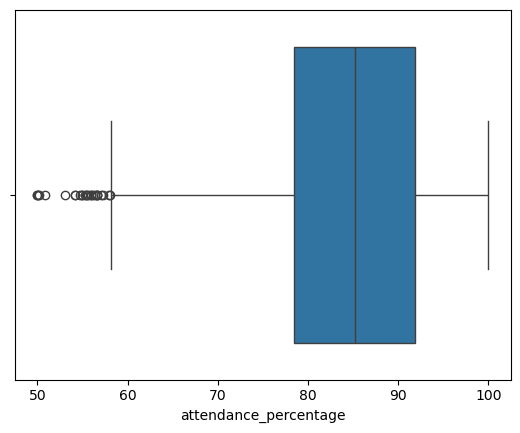

In [109]:
sns.boxplot(x=df["attendance_percentage"])

<Axes: xlabel='weekly_self_study_hours'>

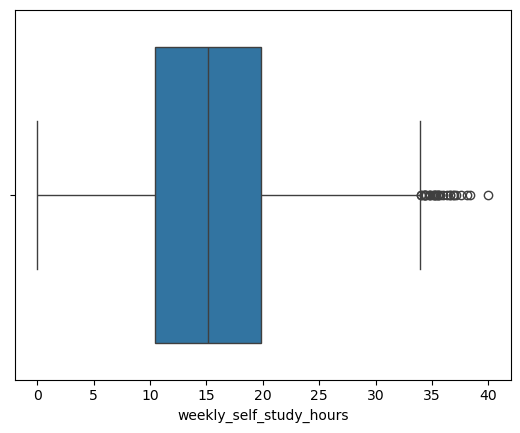

In [110]:
sns.boxplot(x=df["weekly_self_study_hours"])

In [ ]:
def cap_outliers_zscore(df, columns, threshold=3):
    for col in columns:
        mean = df[col].mean()
        std = df[col].std()
        
        upper_limit = mean + threshold * std
        lower_limit = mean - threshold * std
        
        df[col] = df[col].clip(lower_limit, upper_limit)
        
    return df

In [ ]:
df = cap_outliers_zscore(df,num_columns)

In [125]:
X = df.iloc[:,1:-1]

In [126]:
X

,weekly_self_study_hours,attendance_percentage,class_participation
494183,21.7,77.7,8.4
952767,10.0,85.6,4.0
932073,29.2,94.3,2.3
729338,26.3,89.8,3.2
979857,14.2,83.9,4.6
...,...,...,...
152559,10.8,83.5,7.5
920990,12.4,85.8,5.2
347734,10.8,83.7,6.5
697236,19.8,74.6,8.7


In [127]:
y = df.iloc[:,-1]

In [128]:
y

494183    100.0
952767     61.7
932073    100.0
729338     92.5
979857     73.3
          ...  
152559     80.7
920990     83.1
347734     75.9
697236     94.6
89860      90.4
Name: total_score, Length: 10000, dtype: float64

In [129]:
from sklearn.model_selection import train_test_split

In [130]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33, random_state=42)

In [145]:
num_columns=["weekly_self_study_hours","class_participation"]

In [146]:
X_train

,weekly_self_study_hours,attendance_percentage,class_participation
828320,8.7,100.0,5.7
820909,15.5,83.2,7.4
534412,3.2,74.3,4.9
399846,20.5,63.6,5.4
263241,8.0,70.6,4.8
...,...,...,...
30729,14.6,100.0,3.9
57368,13.3,94.1,6.7
990844,20.2,80.5,7.1
138151,29.5,95.3,4.7


In [147]:
y_train

828320     83.0
820909     84.0
534412     43.9
399846     82.4
263241     69.3
          ...  
30729      92.7
57368      88.0
990844     97.2
138151    100.0
579754    100.0
Name: total_score, Length: 6700, dtype: float64

In [148]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline

cube_pipeline = Pipeline([
    ("cube", FunctionTransformer(lambda x: x**3)),
    ("scale", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cube_attendance", cube_pipeline, ["attendance_percentage"]),
        ("num", StandardScaler(), num_columns),
    ]
)

In [149]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

In [150]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cube_attendance', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [151]:
y_pred = pipeline.predict(X_test)

In [152]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.656871175010078


In [185]:
def predictor(a,b,c):
    sample = pd.DataFrame({
    "weekly_self_study_hours": [a],
    "attendance_percentage": [b],
    "class_participation": [c]
})
    pred = pipeline.predict(sample)
    return np.clip(pred, 0, 100)

In [188]:
predictor(42,2,7)

array([100.])